Dataset Shape: (50000, 31)

First 5 rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Certifications  Publications  \
0                No       6.02       6.54  ...               2             0   
1               Yes       5.84       5.12  ...               1             0   
2                No       4.91       5.29  ...               1             0   
3                No       7.67       8.03  ...               2             0   
4                No       8.14       8.97  ...               4             1   

   AptitudeTestScore

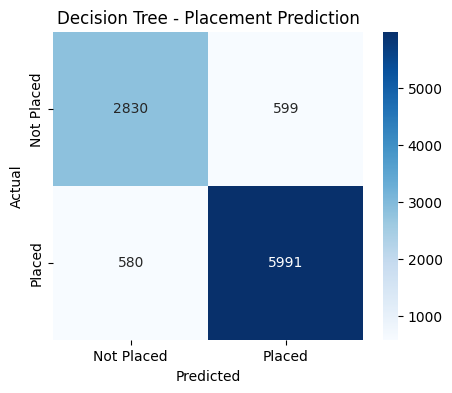

In [1]:
# Decision Tree - Placement Dataset Classification

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier


# ==========================================================
# Step 2: Load Placement Dataset
# ==========================================================

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)


# ==========================================================
# Step 3: Separate Features and Target
# ==========================================================

# Target variable
y = df["PlacementStatus"]

# Remove target column
X = df.drop(columns=["PlacementStatus"])


# ==========================================================
# Step 4: Convert Categorical Columns into Numbers
# ==========================================================

# Find categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("\nCategorical Columns:")
print(categorical_columns)

# Convert categorical data into numerical data
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nShape after encoding:", X.shape)


# ==========================================================
# Step 5: Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ==========================================================
# Step 6: Train the Decision Tree Model
# ==========================================================

model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)


# ==========================================================
# Step 7: Predictions
# ==========================================================

y_pred = model.predict(X_test)


# ==========================================================
# Step 8: Model Evaluation
# ==========================================================

acc = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

print("\n========================================")
print("       DECISION TREE RESULTS")
print("========================================")

print("\nAccuracy:", acc)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)


# ==========================================================
# Step 9: Plot Confusion Matrix
# ==========================================================

plt.figure(figsize=(5, 4))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Placement Prediction")
plt.show()